# What Do People Say? Community Response Analysis
## How Audiences React to Trump vs AOC on Twitter/X

When politicians post on social media, people respond -- sometimes with support, sometimes with criticism, sometimes with humor or outrage. These responses (called **replies** or **comments**) tell us a lot about how citizens participate in political discussions online.

In this notebook, we look at the comments people leave on Trump's and AOC's tweets. We ask simple but important questions:
- **How many** people respond to each politician?
- **How quickly** do they respond?
- **Who** are these commenters? Are they everyday people or high-profile accounts?
- **What tone** do the comments have -- positive, negative, or neutral?
- **What words and topics** come up most often in the comments?

No programming or statistics background is needed to follow this analysis. We explain every concept as it appears.

---

**Key terms you will see in this notebook:**
- **Reply / Comment**: A response someone posts underneath a tweet
- **Average (mean)**: Add up all the numbers and divide by how many there are. For example, if three tweets got 10, 20, and 30 replies, the average is (10+20+30) / 3 = 20 replies.
- **Median (middle value)**: If you line up all the numbers from smallest to largest, the median is the one right in the middle. Unlike the average, the median is not pulled by extreme values.
- **Distribution**: A way of showing how values are spread out -- for example, do most tweets get a few replies, or do reply counts vary wildly?

In [1]:
# --- Setup: Loading the tools and data we need ---
# (This cell loads the software libraries and styling. You can ignore the technical details.)

import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from utils.data_loader import load_tweets, load_replies
from utils.plot_helpers import (
    setup_style, get_colors, get_user_label,
    comparative_bar, comparative_boxplot, comparative_hist,
    format_large_numbers, add_summary_stats
)
from utils.text_helpers import get_word_frequencies, extract_hashtags
from config import FIGURE_SIZE, FIGURE_SIZE_SMALL, FIGURE_SIZE_LARGE, RANDOM_SEED

setup_style()
colors = get_colors()
np.random.seed(RANDOM_SEED)

print('Setup complete.')

Setup complete.


In [2]:
# --- Load the data ---
# We load two datasets:
#   1. The original tweets posted by Trump and AOC
#   2. The replies (comments) that other people left on those tweets

df = load_tweets()
replies_df = load_replies()

print(f"Total tweets collected: {len(df)}")
print(f"Total replies (comments) collected: {len(replies_df)}")
print(f"\nTweets per politician: {df['user'].value_counts().to_dict()}")
print(f"Replies per politician: {replies_df['parent_user'].value_counts().to_dict()}")

Loaded 200 tweets from processed/
Loaded 11403 replies from processed/
Total tweets collected: 200
Total replies (comments) collected: 11403

Tweets per politician: {'aoc': 100, 'trump': 100}
Replies per politician: {'trump': 6741, 'aoc': 4662}


---
## 1. How Many People Reply? Reply Volume Overview

The most basic question we can ask is: **how much conversation does each politician generate?**

When someone posts a tweet and gets thousands of replies, it means the content touched a nerve -- people felt compelled to respond. The number of replies is one of the simplest ways to measure how much a politician's message sparks discussion.

Below, we show three charts side by side:
1. **Total replies collected** -- the raw count of all comments we gathered for each politician
2. **Average replies per tweet** -- on a typical tweet, how many comments does each politician get?
3. **Spread of reply counts** -- do most tweets get a similar number of replies, or do some tweets explode with comments while others get very few?

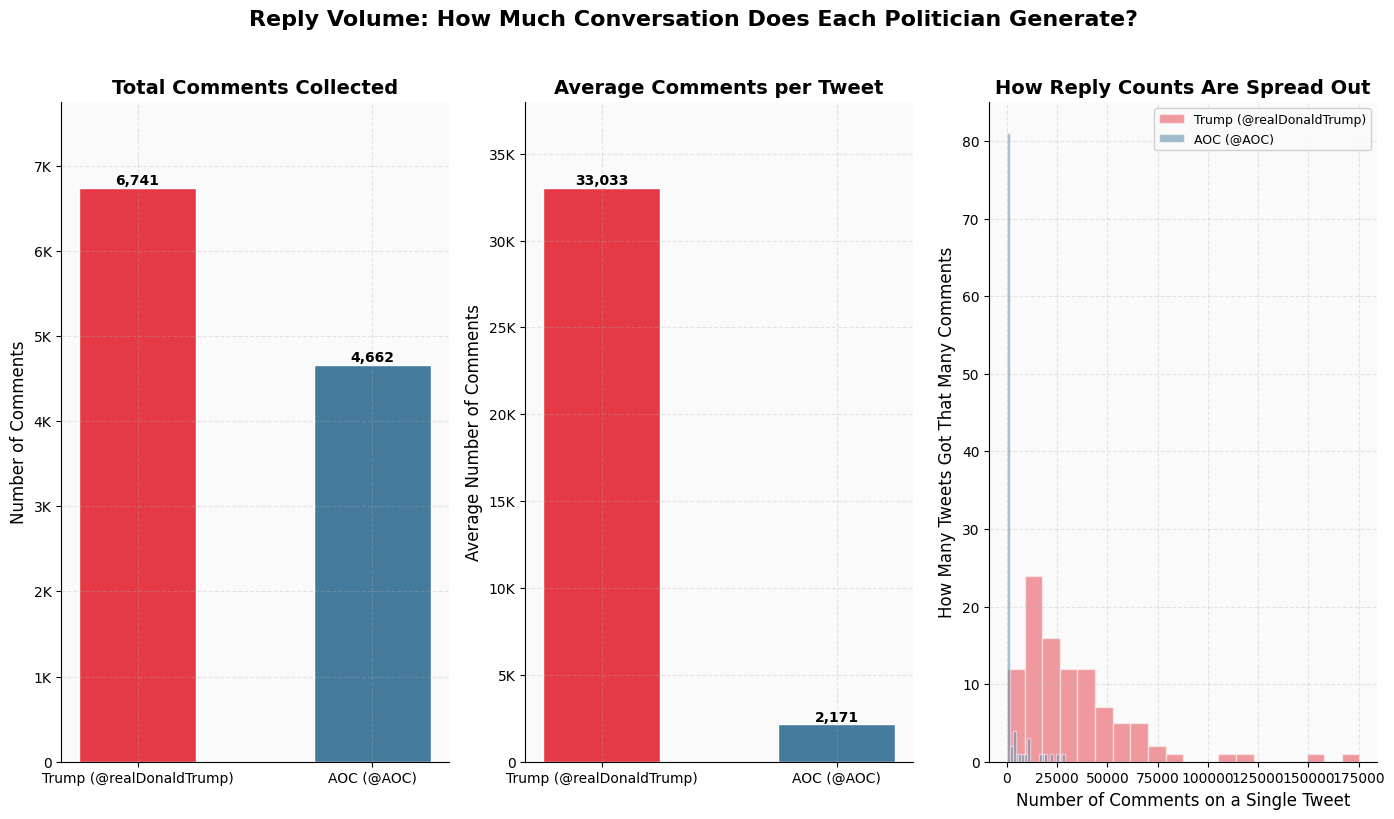

In [3]:
# --- Reply Volume Overview ---
fig, axes = plt.subplots(1, 3, figsize=FIGURE_SIZE_LARGE)

# 1. Total replies per user
ax = axes[0]
users = ['trump', 'aoc']
total_replies = [len(replies_df[replies_df['parent_user'] == u]) for u in users]
user_labels = [get_user_label(u) for u in users]

bars = ax.bar(user_labels, total_replies,
              color=[colors[u] for u in users], width=0.5, edgecolor='white')
for bar, val in zip(bars, total_replies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:,}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Total Comments Collected', fontweight='bold')
ax.set_ylabel('Number of Comments')
ax.set_ylim(0, max(total_replies) * 1.15 if max(total_replies) > 0 else 1)
format_large_numbers(ax)

# 2. Average replies per tweet (from tweets df reply_count)
ax = axes[1]
avg_replies = [df[df['user'] == u]['reply_count'].mean() for u in users]

bars = ax.bar(user_labels, avg_replies,
              color=[colors[u] for u in users], width=0.5, edgecolor='white')
for bar, val in zip(bars, avg_replies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:,.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Average Comments per Tweet', fontweight='bold')
ax.set_ylabel('Average Number of Comments')
ax.set_ylim(0, max(avg_replies) * 1.15 if max(avg_replies) > 0 else 1)
format_large_numbers(ax)

# 3. Histogram of reply_count distribution (from tweets df)
ax = axes[2]
for user in users:
    user_data = df[df['user'] == user]['reply_count'].dropna()
    ax.hist(user_data, bins=20, alpha=0.5, label=get_user_label(user),
            color=colors[user], edgecolor='white')
ax.set_title('How Reply Counts Are Spread Out', fontweight='bold')
ax.set_xlabel('Number of Comments on a Single Tweet')
ax.set_ylabel('How Many Tweets Got That Many Comments')
ax.legend(fontsize=9)

fig.suptitle('Reply Volume: How Much Conversation Does Each Politician Generate?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### What does this tell us?

These charts reveal the **scale of public conversation** each politician generates. A higher total reply count means more people feel the need to respond. The average replies per tweet tells us what a "normal" tweet looks like for each politician. And the spread (the third chart) tells us whether engagement is consistent or driven by a few viral moments.

If one politician's reply counts are clustered tightly together, their audience responds fairly consistently. If the chart is spread out widely, it means some tweets barely get noticed while others spark massive discussions.

In [4]:
# --- Top 10 tweets that got the most comments ---
# Which specific tweets generated the most discussion?

for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user].nlargest(10, 'reply_count')
    
    display_df = user_df[['text', 'reply_count', 'favorite_count']].copy()
    display_df['text'] = display_df['text'].str[:90] + '...'
    display_df = display_df.reset_index(drop=True)
    display_df.index = display_df.index + 1
    display_df.index.name = 'Rank'
    
    display_df['reply_count'] = display_df['reply_count'].apply(lambda x: f"{x:,.0f}")
    display_df['favorite_count'] = display_df['favorite_count'].apply(lambda x: f"{x:,.0f}")
    display_df.columns = ['Tweet Text (first 90 characters)', 'Comments', 'Likes']
    
    print(f"\n{'='*90}")
    print(f"Top 10 Most-Commented Tweets -- {get_user_label(user)}")
    print(f"{'='*90}")
    display(display_df)


Top 10 Most-Commented Tweets -- Trump (@realDonaldTrump)


,Tweet Text (first 90 characters),Comments,Likes
Rank,,,
1,https://t.co/wu9mMkxtUg...,"175,348","1,253,107"
2,https://t.co/2uweRciDEo...,"155,493","1,210,648"
3,https://t.co/lRPhZpugBV...,"121,703","991,735"
4,"Merry Christmas to all, including the Radical ...","110,711","803,067"
5,https://t.co/4sy7jjESGk...,"83,959","595,796"
6,Don’t forget to get a copy of my son Eric’s bo...,"78,070","385,573"
7,These Houthis gathered for instructions on an ...,"70,607","458,675"
8,The United States has a chance to do something...,"66,080","485,527"
9,https://t.co/VoUY2xVnyK...,"65,037","514,714"



Top 10 Most-Commented Tweets -- AOC (@AOC)


,Tweet Text (first 90 characters),Comments,Likes
Rank,,,
1,This is genuinely one of the most disgusting s...,"28,701","120,347"
2,No war with Iran....,"25,565","88,306"
3,It is not a coincidence that after days of Pre...,"22,414","52,141"
4,We exposed the global far-right’s playbook at ...,"18,676","33,200"
5,My having been a waitress makes me 1000x more ...,"17,793","46,580"
6,Americans are being killed in the street by th...,"16,455","177,955"
7,Why does this guy always talk like a World of ...,"11,343","109,787"
8,You are defending the open killing of everyday...,"11,257","132,669"
9,Minnesotans are leading the way. \n\nMass resi...,"10,189","58,785"


### What does this tell us?

Looking at the specific tweets that got the most comments helps us understand **what topics spark the most discussion**. Are they about policy? Personal attacks? Breaking news? The content of these top-commented tweets reveals what the audience cares about most intensely.

Notice whether there is a relationship between likes and comments -- a tweet with many likes but few comments might be something people agree with silently, while a tweet with many comments suggests active debate.

---
## 2. How Quickly Do People Reply? Response Timing

Speed matters in online political discussion. When a politician tweets something controversial or important, **how fast do people jump in to comment?**

The **reply delay** is simply how many minutes pass between when a tweet is posted and when a comment appears. If most replies come within minutes, it suggests the audience is actively monitoring the politician's feed in real-time -- perhaps via notifications or by frequently checking the page.

**New term -- Box plot**: A box plot is a simple chart that shows how data is spread out. The box in the middle shows where the middle 50% of values fall. The line inside the box is the **median** (middle value). The "whiskers" (lines extending from the box) show the wider range, and dots beyond the whiskers are unusual outliers.

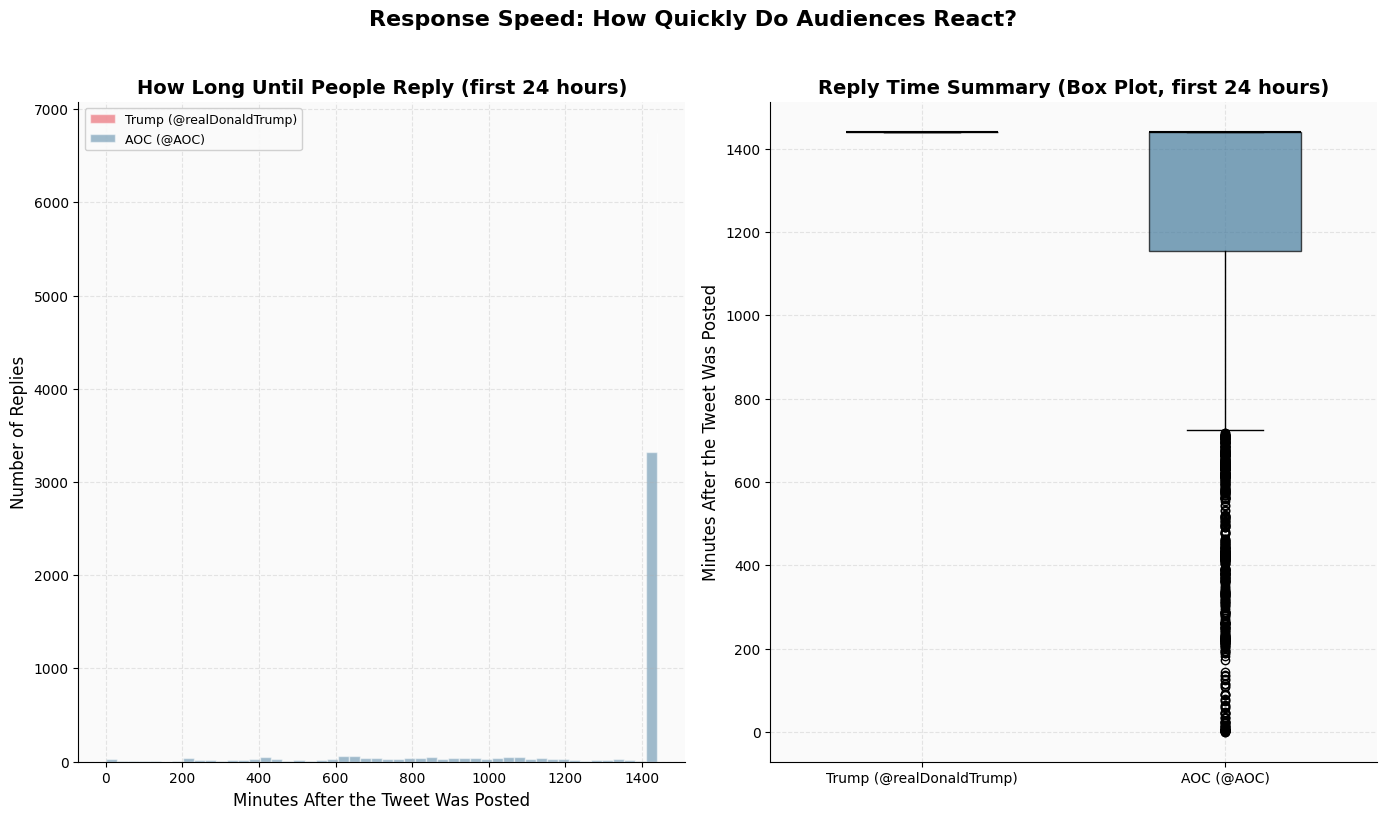


Typical (median) time until a reply appears:
  Trump (@realDonaldTrump): 60736.5 minutes (1012.3 hours)
  AOC (@AOC): 2380.3 minutes (39.7 hours)


In [5]:
# --- How fast do people reply? ---
# We cap the delay at 24 hours (1,440 minutes) so the charts are easier to read.
# Some replies come days later, but we focus on the first 24 hours.

replies_capped = replies_df.copy()
replies_capped['reply_delay_capped'] = replies_capped['reply_delay_minutes'].clip(upper=1440)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

# 1. How reply times are spread out
ax = axes[0]
for user in ['trump', 'aoc']:
    user_data = replies_capped[replies_capped['parent_user'] == user]['reply_delay_capped'].dropna()
    ax.hist(user_data, bins=50, alpha=0.5, label=get_user_label(user),
            color=colors[user], edgecolor='white')
ax.set_title('How Long Until People Reply (first 24 hours)', fontweight='bold')
ax.set_xlabel('Minutes After the Tweet Was Posted')
ax.set_ylabel('Number of Replies')
ax.legend(fontsize=9)

# 2. Box plot of reply delay
ax = axes[1]
users = ['trump', 'aoc']
data = [replies_capped[replies_capped['parent_user'] == u]['reply_delay_capped'].dropna().values
        for u in users]
user_labels = [get_user_label(u) for u in users]

bp = ax.boxplot(data, labels=user_labels, patch_artist=True, widths=0.5,
                medianprops={'color': 'black', 'linewidth': 1.5})
for patch, user in zip(bp['boxes'], users):
    patch.set_facecolor(colors[user])
    patch.set_alpha(0.7)
ax.set_title('Reply Time Summary (Box Plot, first 24 hours)', fontweight='bold')
ax.set_ylabel('Minutes After the Tweet Was Posted')

fig.suptitle('Response Speed: How Quickly Do Audiences React?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print the typical (median) reply delay
print("\nTypical (median) time until a reply appears:")
for user in ['trump', 'aoc']:
    median_delay = replies_df[replies_df['parent_user'] == user]['reply_delay_minutes'].median()
    print(f"  {get_user_label(user)}: {median_delay:.1f} minutes ({median_delay/60:.1f} hours)")

### What does this tell us?

The reply timing charts reveal **how attentive each politician's audience is**. If most replies arrive within the first few minutes, it means people are watching closely -- they may have notifications turned on or check the account frequently.

A shorter typical reply time suggests a more engaged, real-time audience. A longer delay suggests a more casual audience that encounters tweets through browsing rather than active monitoring.

The box plot helps us compare at a glance: a lower box means faster responses overall.

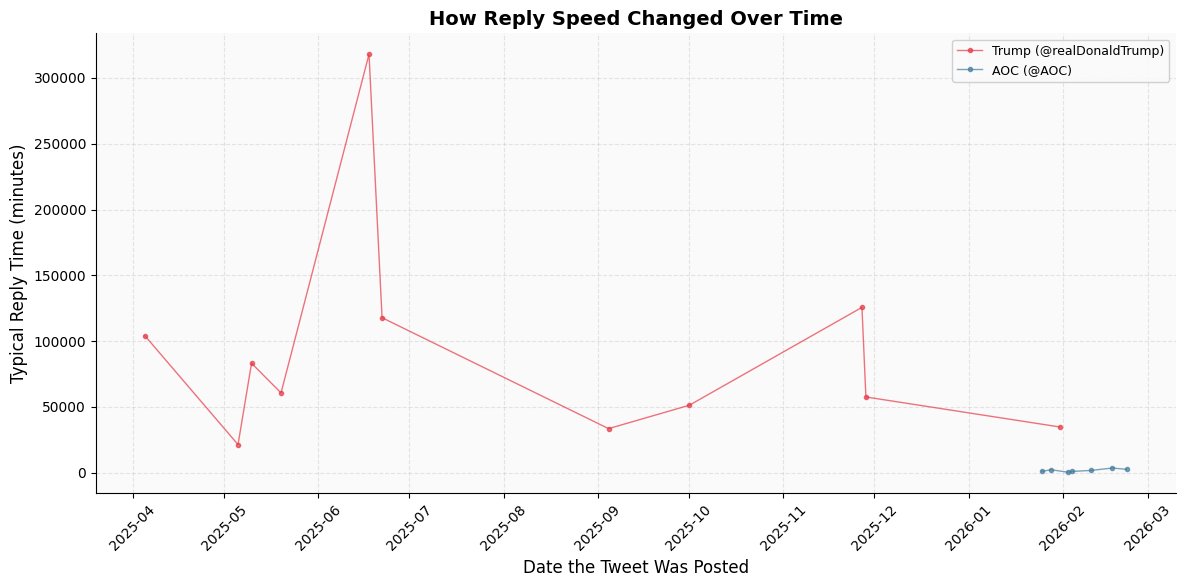

In [6]:
# --- Has reply speed changed over time? ---
# For each tweet, we calculate the typical (median) reply time,
# then plot that over the period we collected data.

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    # Get tweet creation times
    user_tweets = df[df['user'] == user][['tweet_id', 'created_at']].copy()
    user_tweets = user_tweets.sort_values('created_at')
    
    # Compute typical reply delay per tweet
    user_replies = replies_df[replies_df['parent_user'] == user]
    median_delay_per_tweet = user_replies.groupby('parent_tweet_id')['reply_delay_minutes'].median()
    median_delay_per_tweet = median_delay_per_tweet.reset_index()
    median_delay_per_tweet.columns = ['tweet_id', 'median_delay']
    
    # Merge with tweet creation times
    merged = user_tweets.merge(median_delay_per_tweet, on='tweet_id', how='inner')
    merged = merged.sort_values('created_at')
    
    if len(merged) > 0:
        ax.plot(merged['created_at'], merged['median_delay'],
                marker='o', markersize=3, label=get_user_label(user),
                color=colors[user], linewidth=1, alpha=0.7)

ax.set_title('How Reply Speed Changed Over Time', fontweight='bold', fontsize=14)
ax.set_xlabel('Date the Tweet Was Posted')
ax.set_ylabel('Typical Reply Time (minutes)')
ax.legend(fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### What does this tell us?

This time-based chart shows whether audience attentiveness has been **consistent or changing**. If the line trends downward over time, people are replying faster (the audience may be growing more engaged). If it trends upward, response times are slowing.

Sudden spikes or dips often correspond to major events -- a controversial statement, a viral moment, or a news cycle that draws more (or fewer) eyes to that politician's account.

---
## 3. Who Responds? The Profile of Commenters

Not all commenters are the same. Some are everyday citizens with a handful of followers, while others are high-profile accounts with millions of followers. Understanding **who** responds tells us about the nature of each politician's online community.

We look at three characteristics:
1. **How many followers** do the commenters have? This tells us if the conversation is driven by regular people or by influential accounts.
2. **Are commenters verified?** On Twitter/X, there are two types of verification:
   - **Legacy Verified** (the old blue checkmark) -- given to notable public figures, journalists, organizations
   - **Blue Verified (X Premium)** -- available to anyone who pays for a subscription
3. **Who comments the most?** Some people reply to a politician's tweets over and over. These "super-commenters" may be dedicated supporters, persistent critics, or bot accounts.

**New term -- Log scale**: When numbers range from very small (like 1 follower) to very large (like 10 million followers), a regular chart would squish all the small values together. A **log scale** spreads things out so we can see the full range. Each step on the scale represents a 10x increase (1, 10, 100, 1,000, etc.).

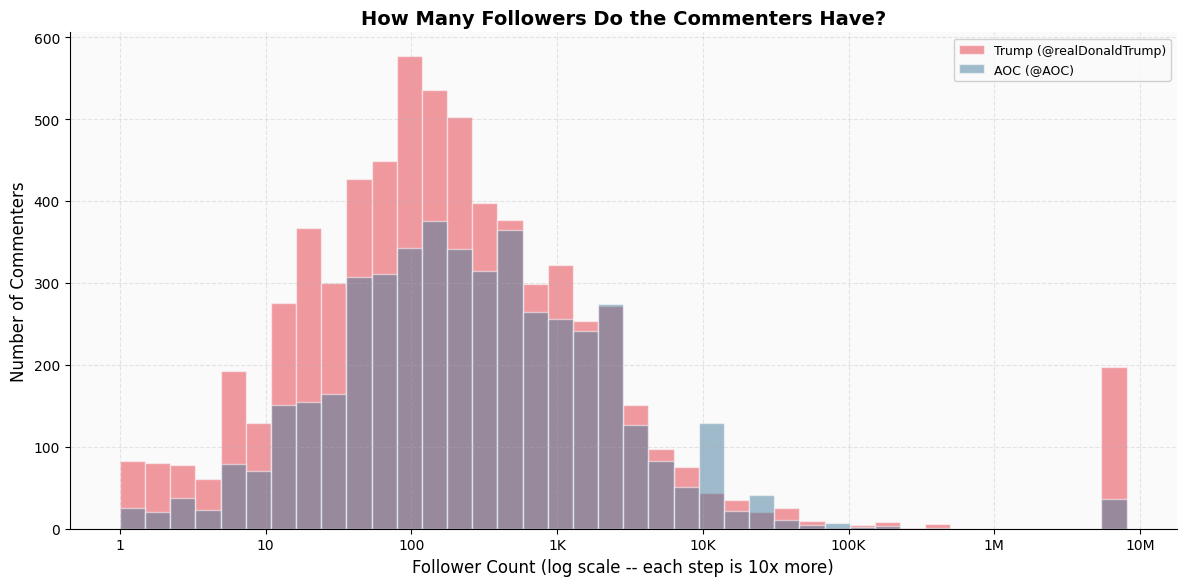


Commenter Follower Count Summary:
(Average = add all up and divide; Median = the middle value)

  Trump (@realDonaldTrump):
    Average:  238,492 followers
    Median:   141 followers
    Largest:  8,103,252 followers

  AOC (@AOC):
    Average:  64,418 followers
    Median:   240 followers
    Largest:  8,104,538 followers


In [7]:
# --- How many followers do the commenters have? ---
fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    user_data = replies_df[replies_df['parent_user'] == user]['user_followers_count'].dropna()
    # Filter to positive values for log scale
    user_data = user_data[user_data > 0]
    ax.hist(np.log10(user_data), bins=40, alpha=0.5, label=get_user_label(user),
            color=colors[user], edgecolor='white')

ax.set_title('How Many Followers Do the Commenters Have?', fontweight='bold', fontsize=14)
ax.set_xlabel('Follower Count (log scale -- each step is 10x more)')
ax.set_ylabel('Number of Commenters')
ax.legend(fontsize=9)

# Add readable labels showing actual follower counts
tick_positions = [0, 1, 2, 3, 4, 5, 6, 7]
tick_labels = ['1', '10', '100', '1K', '10K', '100K', '1M', '10M']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nCommenter Follower Count Summary:")
print("(Average = add all up and divide; Median = the middle value)")
for user in ['trump', 'aoc']:
    user_data = replies_df[replies_df['parent_user'] == user]['user_followers_count'].dropna()
    label = get_user_label(user)
    print(f"\n  {label}:")
    print(f"    Average:  {user_data.mean():,.0f} followers")
    print(f"    Median:   {user_data.median():,.0f} followers")
    print(f"    Largest:  {user_data.max():,.0f} followers")

### What does this tell us?

The follower distribution reveals whether comments come mainly from **everyday users** (accounts with tens or hundreds of followers) or from **influential accounts** (thousands or millions of followers).

Pay attention to the difference between the average and the median. If the average is much higher than the median, it means a few very high-follower accounts are pulling the average up, but most commenters are regular users. This is common in political discussions -- a small number of prominent voices participate alongside a large base of ordinary citizens.

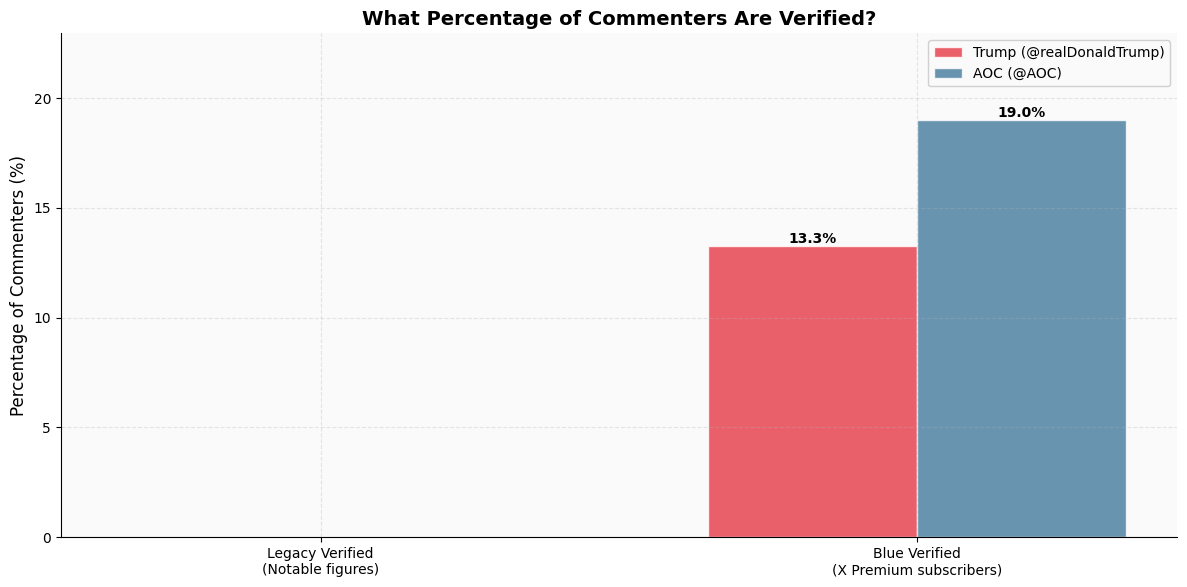

In [8]:
# --- Are the commenters verified? ---
fig, ax = plt.subplots(figsize=FIGURE_SIZE)

users = ['trump', 'aoc']
verification_types = ['Legacy Verified\n(Notable figures)', 'Blue Verified\n(X Premium subscribers)']
x = np.arange(len(verification_types))
width = 0.35

for i, user in enumerate(users):
    user_replies = replies_df[replies_df['parent_user'] == user]
    n_total = len(user_replies)
    
    pct_verified = (user_replies['user_is_verified'].sum() / n_total * 100) if n_total > 0 else 0
    pct_blue = (user_replies['user_is_blue_verified'].sum() / n_total * 100) if n_total > 0 else 0
    
    values = [pct_verified, pct_blue]
    offset = -width / 2 + i * width
    bars = ax.bar(x + offset, values, width, label=get_user_label(user),
                  color=colors[user], alpha=0.8, edgecolor='white')
    
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('What Percentage of Commenters Are Verified?', fontweight='bold', fontsize=14)
ax.set_ylabel('Percentage of Commenters (%)')
ax.set_xticks(x)
ax.set_xticklabels(verification_types)
ax.legend(fontsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.show()

### What does this tell us?

Verification status gives us a rough sense of **who makes up each politician's commenting community**. A higher percentage of Legacy Verified commenters suggests that journalists, public figures, and organizations are engaging in the conversation. A higher percentage of Blue Verified (X Premium) commenters indicates that paying subscribers -- who may be more active or invested users -- participate more.

Differences between the two politicians may reflect the types of audiences they attract: one may draw more institutional/media attention while the other engages a more grassroots audience.

In [9]:
# --- Who comments the most? The "super-commenters" ---
# These are accounts that replied to the same politician's tweets many times.

for user in ['trump', 'aoc']:
    user_replies = replies_df[replies_df['parent_user'] == user]
    
    # Count how many times each person commented
    replier_stats = user_replies.groupby('user_name').agg(
        reply_count=('reply_id', 'count'),
        follower_count=('user_followers_count', 'max')
    ).sort_values('reply_count', ascending=False).head(10)
    
    replier_stats = replier_stats.reset_index()
    replier_stats.index = replier_stats.index + 1
    replier_stats.index.name = 'Rank'
    
    replier_stats['follower_count'] = replier_stats['follower_count'].apply(lambda x: f"{x:,.0f}")
    replier_stats.columns = ['Username', 'Number of Comments', 'Followers']
    
    print(f"\n{'='*70}")
    print(f"Top 10 Most Frequent Commenters -- {get_user_label(user)}")
    print(f"{'='*70}")
    display(replier_stats)


Top 10 Most Frequent Commenters -- Trump (@realDonaldTrump)


,Username,Number of Comments,Followers
Rank,,,
1,grok,197,"8,103,252"
2,Stamina712,40,87
3,piyushforensics,37,62
4,pjk101408,28,107
5,davidcamacaro00,27,"2,379"
6,sheluvvmikeyyyy,26,20
7,ShonBreezy,24,548
8,deafingorange,22,212
9,Pebo007_iam,20,181



Top 10 Most Frequent Commenters -- AOC (@AOC)


,Username,Number of Comments,Followers
Rank,,,
1,teapartytempest,117,"2,460"
2,TheSportPigeon,99,"11,229"
3,grok,36,"8,104,538"
4,Darealynsny,32,41
5,TokyoRobb,24,516
6,GerryRiver55569,19,921
7,PopTartsdSmores,17,151
8,CaptJCurcioUSMC,16,"1,637"
9,SaltyGoodness1,16,160


### What does this tell us?

The "super-commenters" are people who reply over and over to a politician's tweets. They might be:
- **Dedicated supporters** who consistently show up to defend their politician
- **Persistent critics** who oppose everything the politician says
- **Bot or automated accounts** programmed to reply automatically
- **Activist accounts** trying to amplify a particular message

Looking at the follower counts of these top commenters helps us understand whether the most active voices are influential accounts or smaller accounts with outsized participation.

---
## 4. Are Comments Positive or Negative? Sentiment Analysis

Beyond counting comments, we want to understand the **emotional tone** of the conversation. Are people responding with support and praise, or with criticism and anger?

**How we measured this (sentiment analysis explained simply):**
We used a computer to check if comments sound positive, negative, or neutral by looking for key words. For example:
- Words like **"great," "love," "amazing," "thank you"** suggest a **positive** tone
- Words like **"terrible," "hate," "stupid," "liar"** suggest a **negative** tone
- If a comment has roughly equal positive and negative words, or no strong words either way, it is classified as **neutral**

This is a simplified approach -- it cannot detect sarcasm or subtle meaning -- but it gives us a useful big-picture view of the emotional reactions from the community.

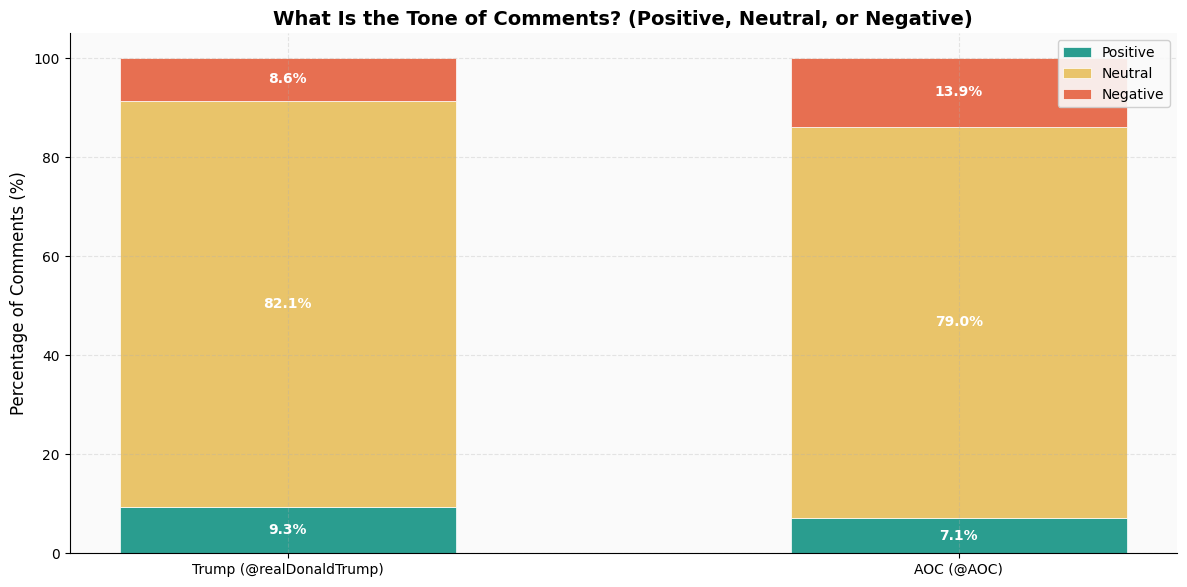


Exact Percentages:

  Trump (@realDonaldTrump):
    Positive  : 9.29%
    Neutral   : 82.11%
    Negative  : 8.60%

  AOC (@AOC):
    Positive  : 7.10%
    Neutral   : 79.02%
    Negative  : 13.88%


In [10]:
# --- What is the overall tone of comments? ---
fig, ax = plt.subplots(figsize=FIGURE_SIZE)

sentiment_order = ['positive', 'neutral', 'negative']
sentiment_colors = {'positive': '#2a9d8f', 'neutral': '#e9c46a', 'negative': '#e76f51'}

users = ['trump', 'aoc']
proportions = {}

for user in users:
    user_replies = replies_df[replies_df['parent_user'] == user]
    counts = user_replies['sentiment_simple'].value_counts()
    total = counts.sum()
    proportions[user] = {s: (counts.get(s, 0) / total * 100) if total > 0 else 0
                         for s in sentiment_order}

# Stacked bar chart
x = np.arange(len(users))
width = 0.5
bottom = np.zeros(len(users))

for sentiment in sentiment_order:
    values = [proportions[u][sentiment] for u in users]
    bars = ax.bar(x, values, width, bottom=bottom,
                  label=sentiment.capitalize(), color=sentiment_colors[sentiment],
                  edgecolor='white', linewidth=0.5)
    
    # Add percentage labels in the middle of each segment
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 3:  # Only label segments > 3% for readability
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottom[j] + val / 2,
                    f"{val:.1f}%", ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
    bottom += values

ax.set_title('What Is the Tone of Comments? (Positive, Neutral, or Negative)',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Percentage of Comments (%)')
ax.set_xticks(x)
ax.set_xticklabels([get_user_label(u) for u in users])
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

# Print exact percentages
print("\nExact Percentages:")
for user in users:
    print(f"\n  {get_user_label(user)}:")
    for sentiment in sentiment_order:
        print(f"    {sentiment.capitalize():10s}: {proportions[user][sentiment]:.2f}%")

### What does this tell us?

The sentiment breakdown reveals the **emotional atmosphere** of each politician's comment section. A higher proportion of negative comments suggests the politician faces more opposition or controversy in their replies. A higher proportion of positive comments suggests a more supportive audience.

It is important to note that political Twitter/X tends to attract strong opinions, so both politicians may have substantial negative sentiment. The key comparison is whether one politician's comment section is significantly more hostile or supportive than the other's.

Remember: neutral does not mean "indifferent" -- it may include factual responses, questions, or comments that simply do not contain strong positive or negative keywords.

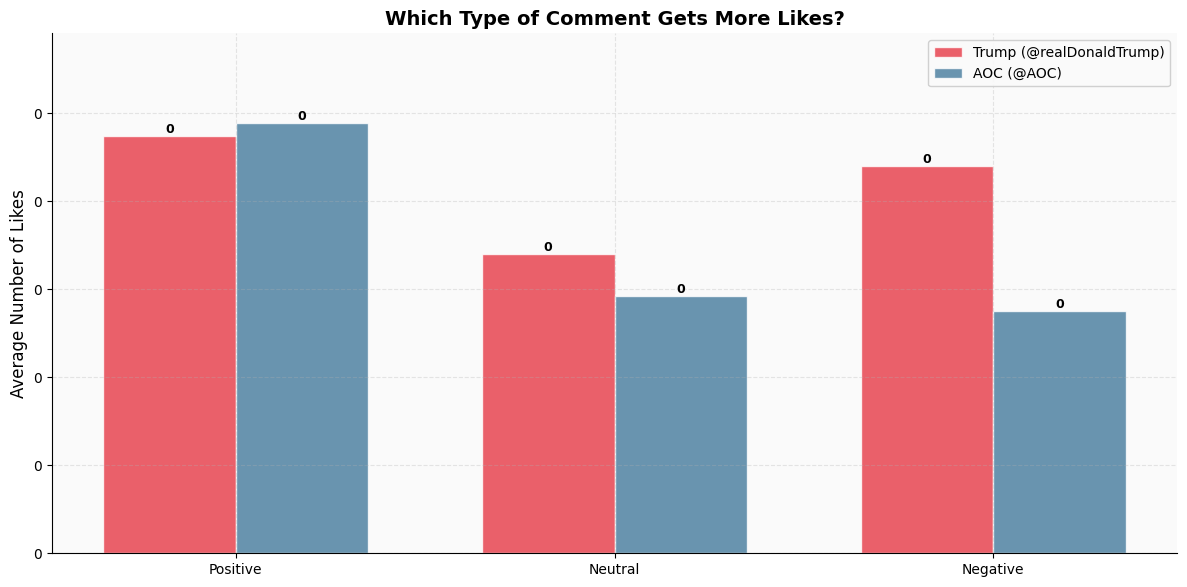

In [11]:
# --- Do positive or negative comments get more likes? ---
# This tells us what kind of tone the wider audience rewards.

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

sentiment_order = ['positive', 'neutral', 'negative']
users = ['trump', 'aoc']
x = np.arange(len(sentiment_order))
width = 0.35

for i, user in enumerate(users):
    user_replies = replies_df[replies_df['parent_user'] == user]
    means = []
    for sentiment in sentiment_order:
        subset = user_replies[user_replies['sentiment_simple'] == sentiment]
        means.append(subset['favorite_count'].mean() if len(subset) > 0 else 0)
    
    offset = -width / 2 + i * width
    bars = ax.bar(x + offset, means, width, label=get_user_label(user),
                  color=colors[user], alpha=0.8, edgecolor='white')
    
    for bar, val in zip(bars, means):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Which Type of Comment Gets More Likes?', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Number of Likes')
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in sentiment_order])
ax.legend(fontsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
format_large_numbers(ax)
plt.tight_layout()
plt.show()

### What does this tell us?

This chart reveals **what the broader audience rewards**. If negative comments get more likes, it suggests the audience (or at least the majority of people seeing those replies) is more oppositional. If positive comments get more likes, the audience leans supportive.

This is an important distinction: the tone of comments tells us what people *write*, but the likes on those comments tell us what the *wider audience agrees with*. These two things can tell very different stories.

In [12]:
# --- Most liked positive and negative comments ---
# These are the specific comments that resonated most with each audience.

for user in ['trump', 'aoc']:
    user_replies = replies_df[replies_df['parent_user'] == user]
    label = get_user_label(user)
    
    for sentiment in ['positive', 'negative']:
        subset = user_replies[user_replies['sentiment_simple'] == sentiment]
        top5 = subset.nlargest(5, 'favorite_count')
        
        display_df = top5[['user_name', 'text', 'favorite_count']].copy()
        display_df['text'] = display_df['text'].str[:100] + '...'
        display_df['favorite_count'] = display_df['favorite_count'].apply(lambda x: f"{x:,.0f}")
        display_df = display_df.reset_index(drop=True)
        display_df.index = display_df.index + 1
        display_df.index.name = 'Rank'
        display_df.columns = ['Username', 'Comment Text (first 100 characters)', 'Likes']
        
        print(f"\n{'='*90}")
        print(f"Top 5 Most-Liked {sentiment.capitalize()} Comments -- {label}")
        print(f"{'='*90}")
        display(display_df)


Top 5 Most-Liked Positive Comments -- Trump (@realDonaldTrump)


,Username,Comment Text (first 100 characters),Likes
Rank,,,
1,SimonaMangiante,@realDonaldTrump Thank you @realDonaldTrump fo...,15
2,AGHuff,@realDonaldTrump Self deportation is the best ...,7
3,Litsing1Jannine,@k_ovfefe2 @realDonaldTrump Such intelligent y...,6
4,MAGAShagster,@realDonaldTrump Great plan and It's more than...,6
5,TheWiseMosaic,@realDonaldTrump Is it still the case that Gen...,5



Top 5 Most-Liked Negative Comments -- Trump (@realDonaldTrump)


,Username,Comment Text (first 100 characters),Likes
Rank,,,
1,FrankDangelo23,@realDonaldTrump You snubbed supreme court jud...,37
2,Achilles440617,"@realDonaldTrump POTUS @realDonaldTrump, any f...",26
3,mariclarecj,@JamesSmith15941 I strongly recommend you to r...,6
4,dianagrace61,@realDonaldTrump Putin is laughing at you! wha...,5
5,Jampie111,@realDonaldTrump In the Netherlands we will be...,3



Top 5 Most-Liked Positive Comments -- AOC (@AOC)


,Username,Comment Text (first 100 characters),Likes
Rank,,,
1,TheUnitedSpot__,@AOC @DianaforQueens Congratulations AOC for b...,35
2,Bmmoody,@AOC @DianaforQueens Universal childcare sound...,24
3,Wess_Miller,"@AOC @DianaforQueens @AOC, thank you for leadi...",8
4,Simply4Truth_,"@AOC @SenateDems ""Thank you to all who mobiliz...",4
5,WitCephandrius,@grok @DavidLHillPA @AOC Thanks Grok. Democrat...,3



Top 5 Most-Liked Negative Comments -- AOC (@AOC)


,Username,Comment Text (first 100 characters),Likes
Rank,,,
1,existensil,@Bmmoody @AOC @DianaforQueens Even countries t...,8
2,bugaroo19,@AOC @SenateDems The victims of illegals don't...,7
3,MissDanger_3,@AOC @SenateDems AOC I saw your name in this n...,6
4,wgedwards60,@BillFeuer @GuntherEagleman @AOC @Acyn She dro...,3
5,RealRichardGC,@AOC I would choose a dog before a muslim any ...,3


### What does this tell us?

Reading the actual text of the most popular comments gives us **qualitative insight** that numbers alone cannot provide. These are the voices that resonated most with the audience.

Ask yourself: Are the most popular positive comments expressing genuine admiration, or are they partisan cheerleading? Are the most popular negative comments substantive criticism, or personal attacks? The nature of these top comments reveals the quality and character of political discourse in each community.

---
## 5. Engagement Within the Comments

When someone replies to a politician's tweet, that reply can itself receive likes, retweets, and views. This is what we call **engagement within the comments** -- the conversation that happens *about the conversation*.

When a reply gets many likes, it means the audience found that response valuable, funny, or agreeable. High engagement within the comments signals that the discussion in the reply threads has its own audience and importance -- it is not just background noise, but an active arena of political discussion.

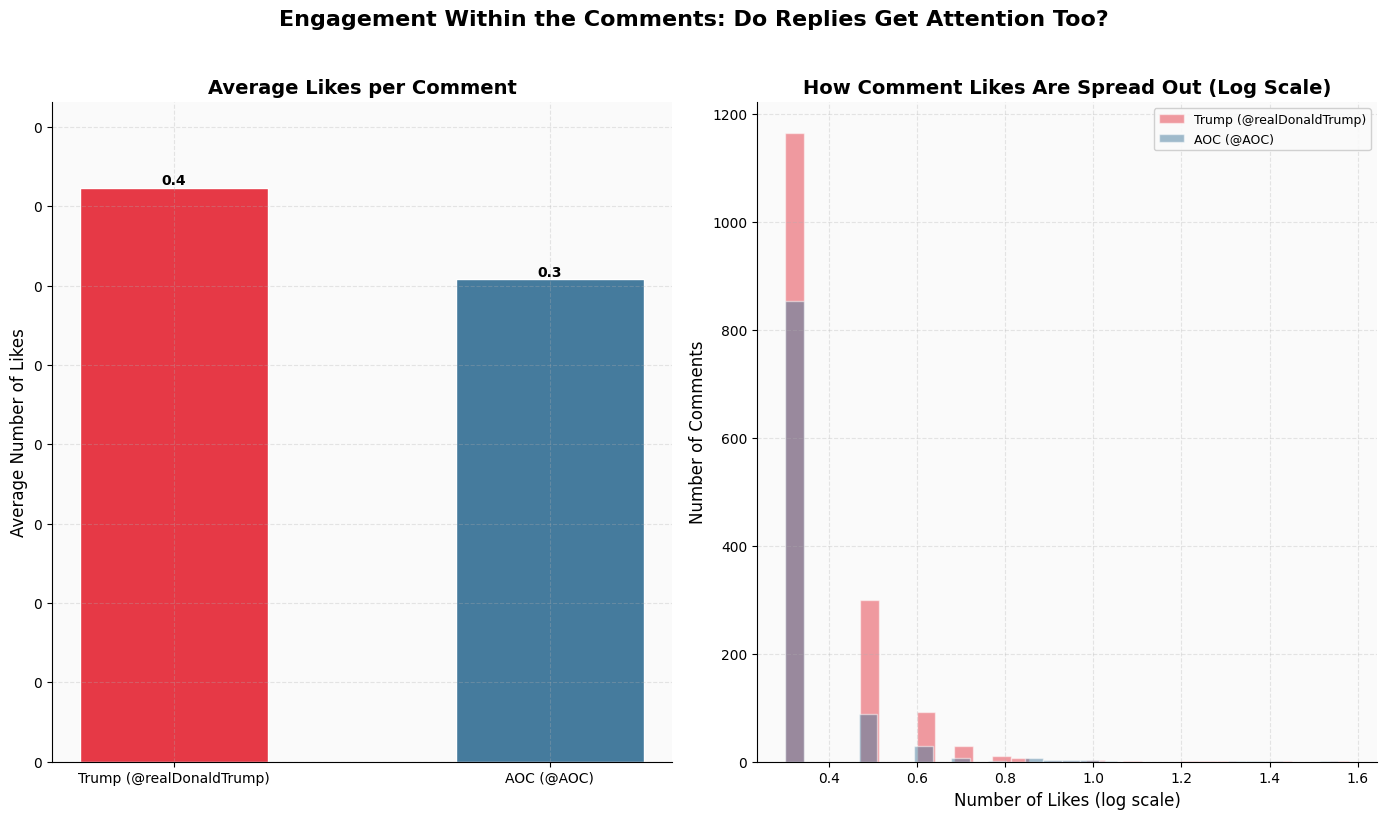


Most Liked Comment for Each Politician:

  Trump (@realDonaldTrump):
    By: @FrankDangelo23
    Likes: 37
    Retweets: 17
    Text: @realDonaldTrump You snubbed supreme court judges!!! as you walked by them! because they had the integrity &amp; the balls to follow the law &amp; the...

  AOC (@AOC):
    By: @TheUnitedSpot__
    Likes: 35
    Retweets: 1
    Text: @AOC @DianaforQueens Congratulations AOC for being a retard. Actually, you make retards look smart, you’re lower than a retard, it’s an insult to reta...


In [13]:
# --- How much attention do the comments themselves receive? ---
fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

# 1. Average likes per comment
ax = axes[0]
users = ['trump', 'aoc']
mean_fav = [replies_df[replies_df['parent_user'] == u]['favorite_count'].mean() for u in users]
user_labels = [get_user_label(u) for u in users]

bars = ax.bar(user_labels, mean_fav,
              color=[colors[u] for u in users], width=0.5, edgecolor='white')
for bar, val in zip(bars, mean_fav):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:,.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Average Likes per Comment', fontweight='bold')
ax.set_ylabel('Average Number of Likes')
ax.set_ylim(0, max(mean_fav) * 1.15 if max(mean_fav) > 0 else 1)
format_large_numbers(ax)

# 2. How are comment likes spread out?
ax = axes[1]
for user in users:
    user_data = replies_df[replies_df['parent_user'] == user]['favorite_count'].dropna()
    # Use log scale for better visualization (most comments get few likes, some get many)
    user_data_log = user_data[user_data > 0]
    if len(user_data_log) > 0:
        ax.hist(np.log10(user_data_log + 1), bins=30, alpha=0.5,
                label=get_user_label(user), color=colors[user], edgecolor='white')

ax.set_title('How Comment Likes Are Spread Out (Log Scale)', fontweight='bold')
ax.set_xlabel('Number of Likes (log scale)')
ax.set_ylabel('Number of Comments')
ax.legend(fontsize=9)

fig.suptitle('Engagement Within the Comments: Do Replies Get Attention Too?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Most liked comment overall for each politician
print("\nMost Liked Comment for Each Politician:")
for user in ['trump', 'aoc']:
    user_replies = replies_df[replies_df['parent_user'] == user]
    if len(user_replies) > 0:
        top_reply = user_replies.loc[user_replies['favorite_count'].idxmax()]
        print(f"\n  {get_user_label(user)}:")
        print(f"    By: @{top_reply['user_name']}")
        print(f"    Likes: {top_reply['favorite_count']:,.0f}")
        print(f"    Retweets: {top_reply['retweet_count']:,.0f}")
        print(f"    Text: {str(top_reply['text'])[:150]}...")

### What does this tell us?

When comments themselves receive lots of likes, it means the reply section has become **a conversation in its own right** -- not just a space for one-way responses, but an active forum where people engage with each other's ideas.

Higher engagement within the comments suggests a more vibrant, participatory community. It also means that individual voices in the reply section can reach large audiences, amplifying certain perspectives and shaping the narrative around a politician's tweets.

---
## 6. What Are People Talking About? Words and Hashtags in the Comments

Beyond tone, we want to know **what topics and themes** dominate the comment sections. By looking at the most common words and hashtags used in replies, we can identify the concerns, slogans, and ideas that each politician's audience cares about most.

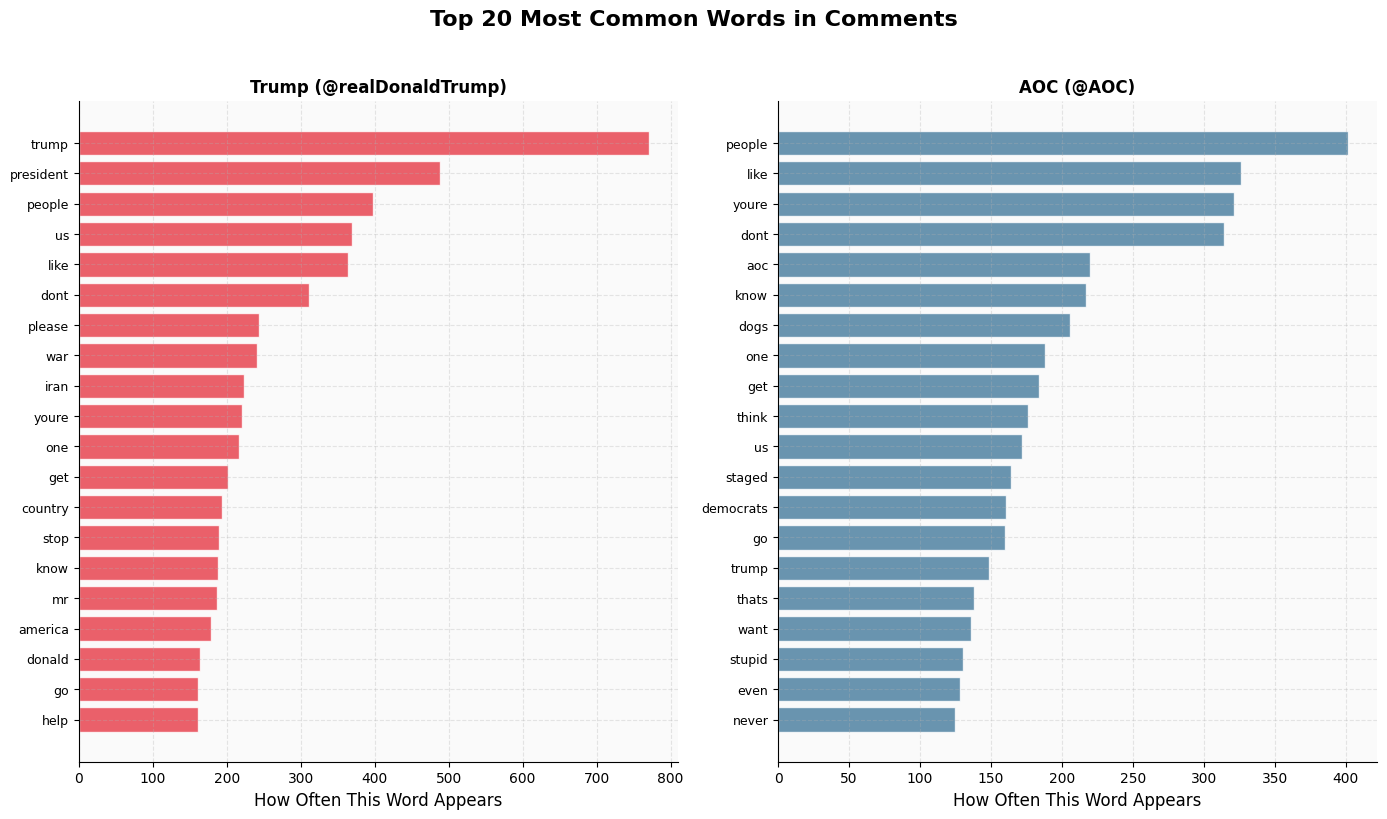

In [14]:
# --- What are the most common words in the comments? ---
fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

for idx, user in enumerate(['trump', 'aoc']):
    ax = axes[idx]
    user_replies = replies_df[replies_df['parent_user'] == user]
    texts = user_replies['text'].dropna().tolist()
    
    # Get the 20 most common words (excluding common words like "the", "and", etc.)
    word_freqs = get_word_frequencies(texts, top_n=20)
    
    if word_freqs:
        words = [w for w, c in word_freqs]
        counts = [c for w, c in word_freqs]
        
        y_pos = np.arange(len(words))
        ax.barh(y_pos, counts, color=colors[user], alpha=0.8, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('How Often This Word Appears')
    
    ax.set_title(f'{get_user_label(user)}', fontweight='bold', fontsize=12)

fig.suptitle('Top 20 Most Common Words in Comments', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### What does this tell us?

The most common words reveal **what topics dominate each conversation**. Look for:
- **Names** (of the politician, opponents, or public figures) -- showing who the audience is focused on
- **Policy-related words** -- showing which issues matter to the audience
- **Emotional words** -- showing the overall mood
- **Action words** ("vote," "fight," "support") -- showing whether the audience is being mobilized

Comparing the two side by side tells us whether these two political communities are talking about the same things or living in entirely different information worlds.

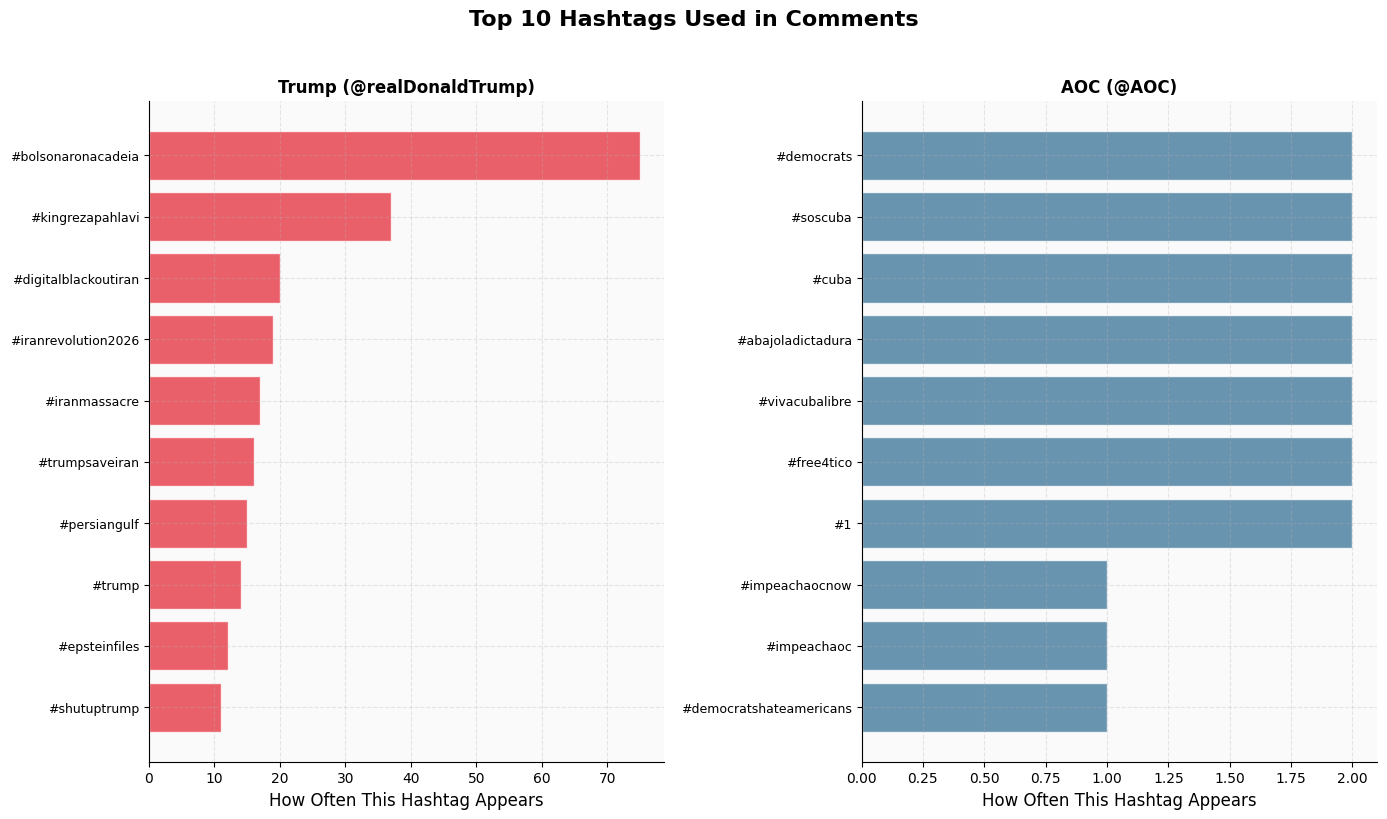

In [15]:
# --- What hashtags do commenters use? ---
# Hashtags (words starting with #) are labels people use to connect their comment
# to a broader topic or movement.

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

for idx, user in enumerate(['trump', 'aoc']):
    ax = axes[idx]
    user_replies = replies_df[replies_df['parent_user'] == user]
    
    # Extract all hashtags from comment texts
    all_hashtags = []
    for text in user_replies['text'].dropna():
        all_hashtags.extend([h.lower() for h in extract_hashtags(text)])
    
    # Count and get top 10
    if all_hashtags:
        hashtag_counts = pd.Series(all_hashtags).value_counts().head(10)
        
        y_pos = np.arange(len(hashtag_counts))
        ax.barh(y_pos, hashtag_counts.values, color=colors[user], alpha=0.8, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels([f'#{h}' for h in hashtag_counts.index], fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('How Often This Hashtag Appears')
    else:
        ax.text(0.5, 0.5, 'No hashtags found', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, color='gray')
    
    ax.set_title(f'{get_user_label(user)}', fontweight='bold', fontsize=12)

fig.suptitle('Top 10 Hashtags Used in Comments', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### What does this tell us?

Hashtags are like **banners or slogans** that commenters wave. They connect individual replies to larger political movements, campaigns, or issues. The most popular hashtags reveal:
- **Political affiliations** (party-related hashtags)
- **Issue campaigns** (hashtags about specific policies or causes)
- **Opposition messages** (hashtags used to criticize or mock)
- **Viral moments** (hashtags tied to current events)

If both politicians' comment sections share many of the same hashtags, their audiences overlap and engage with the same issues. If the hashtags are very different, the two communities exist in separate political worlds.

---
## 7. Summary Table: Community Response at a Glance

This table brings together all the key numbers from the sections above into one easy-to-compare view.

In [16]:
# --- Comparison Summary Table ---
summary_data = []

for user in ['trump', 'aoc']:
    user_replies = replies_df[replies_df['parent_user'] == user]
    user_tweets = df[df['user'] == user]
    n_replies = len(user_replies)
    
    # Total replies
    total_replies = n_replies
    
    # Avg replies per tweet
    avg_replies_per_tweet = user_tweets['reply_count'].mean()
    
    # Median reply delay
    median_delay = user_replies['reply_delay_minutes'].median()
    
    # Sentiment percentages
    sent_counts = user_replies['sentiment_simple'].value_counts()
    pct_positive = (sent_counts.get('positive', 0) / n_replies * 100) if n_replies > 0 else 0
    pct_negative = (sent_counts.get('negative', 0) / n_replies * 100) if n_replies > 0 else 0
    
    # Mean replier followers
    mean_followers = user_replies['user_followers_count'].mean()
    
    # % verified repliers (legacy or blue)
    pct_verified = (
        (user_replies['user_is_verified'].sum() + user_replies['user_is_blue_verified'].sum())
        / n_replies * 100
    ) if n_replies > 0 else 0
    
    # Most liked reply
    if n_replies > 0:
        top_reply = user_replies.loc[user_replies['favorite_count'].idxmax()]
        most_liked_text = str(top_reply['text'])[:60] + '...'
        most_liked_likes = int(top_reply['favorite_count'])
    else:
        most_liked_text = 'N/A'
        most_liked_likes = 0
    
    summary_data.append({
        'Metric': get_user_label(user),
        'Total Comments': f"{total_replies:,}",
        'Avg Comments per Tweet': f"{avg_replies_per_tweet:,.0f}",
        'Typical Reply Time (min)': f"{median_delay:,.1f}",
        '% Positive Comments': f"{pct_positive:.1f}%",
        '% Negative Comments': f"{pct_negative:.1f}%",
        'Avg Commenter Followers': f"{mean_followers:,.0f}",
        '% Verified Commenters': f"{pct_verified:.1f}%",
        f'Most Liked Comment ({most_liked_likes:,} likes)': most_liked_text,
    })

summary_df = pd.DataFrame(summary_data).set_index('Metric').T
summary_df.index.name = 'Metric'

styled = summary_df.style.set_caption(
    'Community Response Comparison: Trump vs AOC'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
    {'selector': 'th', 'props': [('text-align', 'left')]},
    {'selector': 'td', 'props': [('text-align', 'center')]},
])

display(styled)

Metric,Trump (@realDonaldTrump),AOC (@AOC)
Metric,,
Total Comments,"6,741","4,662"
Avg Comments per Tweet,"33,033","2,171"
Typical Reply Time (min),"60,736.5","2,380.3"
% Positive Comments,9.3%,7.1%
% Negative Comments,8.6%,13.9%
Avg Commenter Followers,"238,492","64,418"
% Verified Commenters,13.3%,19.0%
Most Liked Comment (37 likes),@realDonaldTrump You snubbed supreme court judges!!! as you ...,nan
Most Liked Comment (35 likes),nan,@AOC @DianaforQueens Congratulations AOC for being a retard....


---
## 8. Key Takeaways: What Community Responses Tell Us About Political Discourse

After analyzing thousands of comments on Trump's and AOC's tweets, here is what we found:

**1. Scale of conversation differs dramatically.** The sheer volume of replies each politician receives reflects their different positions in the political landscape. The politician with more replies is not necessarily more popular -- they may simply be more controversial, generating both support and opposition.

**2. Reply speed reveals audience dedication.** The time it takes for comments to appear tells us how closely each audience monitors their politician. Faster replies suggest a more devoted, real-time following that actively watches for new content, while slower replies indicate a more casual audience that encounters tweets through algorithmic recommendation.

**3. Comment sections are dominated by regular people, not elites.** The vast majority of commenters have relatively modest follower counts, showing that political discussion on Twitter/X is driven by ordinary citizens rather than media figures or celebrities. However, the small number of high-follower accounts that do participate can disproportionately shape the conversation.

**4. The emotional tone of comments reveals the character of each community.** The balance between positive, negative, and neutral comments tells us whether a politician's reply section functions more as a supportive community or as a contested battleground. Neither pattern is inherently better -- both reflect how citizens participate in political discussions online.

**5. What gets rewarded matters as much as what gets said.** The types of comments that receive the most likes reveal what the broader audience values. If critical comments are rewarded with likes, opposition voices are amplified. If supportive comments are rewarded, the community reinforces loyalty.

**6. Word choices and hashtags reveal separate political worlds.** The most common words and hashtags in each comment section show that Trump's and AOC's audiences may be discussing entirely different topics, reflecting the polarization of political conversation in digital spaces.

**7. Reply sections have become a political arena in their own right.** When comments themselves receive thousands of likes and retweets, the comment section is no longer just a reaction to the original tweet -- it becomes an independent space for political expression, debate, and mobilization. This shows how social media has transformed political communication from a one-way broadcast into a multi-layered conversation.

---
*These findings complement the content and engagement analyses from previous notebooks, building toward a comprehensive picture of digital political discourse.*